## Setting up data

In [2]:
import pandas as pd
from data_cleaning.parse_visitors import parse_visitor_data

# load raw csvs
visitors = pd.read_csv("../source/visitors.csv")
answers = pd.read_csv("../source/visitors_answers.csv")
questions = pd.read_csv("../source/visitors_questions.csv")

In [3]:
# parse
visitor_data = parse_visitor_data(visitors, answers, questions)
visitor_data.head()


,email,gender,visitorId,stepId,questionId,answerValue,answerId,answerTypeId,answer,questionTypeId,question
14,emilija+100_L8gA@bss.mk,F,67b70a9f2d21f543a1096602,5c8a78336d41a10da4f730fd,5c8a78336d41a10da4f730fe,,5c8a78336d41a10da4f73100,Answer,To obtain general information,5bf7c399b82beb7a182cc3de,Reason for Attending the Event
20,emilija+100_L8gA@bss.mk,F,67b70a9f2d21f543a1096602,5c8a78336d41a10da4f73225,5c8a78336d41a10da4f73227,,5c8a78336d41a10da4f73244,Answer,Media,5bf7c399b82beb7a182cc3de,Which of the following best describes your job...
23,emilija+100_L8gA@bss.mk,F,67b70a9f2d21f543a1096602,5c8a78336d41a10da4f73252,5c8a78336d41a10da4f73253,,5c8a78336d41a10da4f73291,Answer,Travel Agent,5bf7c399b82beb7a182cc3de,Please indicate your company's main area of bu...
31,emilija+100_L8gA@bss.mk,F,67b70a9f2d21f543a1096602,5c8a78336d41a10da4f7336c,5c8a78336d41a10da4f7336d,,5c8a78336d41a10da4f73371,Answer,No influence,5bf7c399b82beb7a182cc3de,What role do you play in the purchasing decisi...
47,aleksandar.dimkov+mitt1_n5eA@bss.com.mk,M,67ada1ee197e604dd2722d1b,5c8a78336d41a10da4f730fd,5c8a78336d41a10da4f730fe,,5c8a78336d41a10da4f730ff,Answer,To source products and services,5bf7c399b82beb7a182cc3de,Reason for Attending the Event


## Performing analysis

### Gender distribution

In [4]:
# distribution of gender across visitors
visitor_data[['visitorId', 'gender']].drop_duplicates().groupby('gender').count()

,visitorId
gender,
F,45
M,55


### Clarifying quality of answers by visitors

Inspecting answers column

In [5]:
visitor_data.answer.unique().tolist()

['To obtain general information',
 'Media',
 'Travel Agent',
 'No influence',
 'To source products and services',
 'Sales',
 'Event management',
 'Sole responsibility',
 '5 - 10 million rubles',
 'To promote products and services',
 'Formation of tourist products',
 'Joint responsibility',
 'Up to 1 million rubles',
 nan,
 'Advisory role',
 'Visa support',
 'Tour Operator',
 'IT solutions for travel industry',
 '1 - 5 million rubles',
 'Accommodation Provider',
 'Guided tour services',
 'Educational purposes ',
 'Marketing',
 'Personal interest']

It looks like answerValue column is null if the question is not null! Lets assume that the answer colum is the set of valid answers provided by the visitors.

In [ ]:
visitor_data = visitor_data[~visitor_data['question'].isnull()]
visitor_data.head()

,email,gender,visitorId,stepId,questionId,answerValue,answerId,answerTypeId,answer,questionTypeId,question
14,emilija+100_L8gA@bss.mk,F,67b70a9f2d21f543a1096602,5c8a78336d41a10da4f730fd,5c8a78336d41a10da4f730fe,,5c8a78336d41a10da4f73100,Answer,To obtain general information,5bf7c399b82beb7a182cc3de,Reason for Attending the Event
20,emilija+100_L8gA@bss.mk,F,67b70a9f2d21f543a1096602,5c8a78336d41a10da4f73225,5c8a78336d41a10da4f73227,,5c8a78336d41a10da4f73244,Answer,Media,5bf7c399b82beb7a182cc3de,Which of the following best describes your job...
23,emilija+100_L8gA@bss.mk,F,67b70a9f2d21f543a1096602,5c8a78336d41a10da4f73252,5c8a78336d41a10da4f73253,,5c8a78336d41a10da4f73291,Answer,Travel Agent,5bf7c399b82beb7a182cc3de,Please indicate your company's main area of bu...
31,emilija+100_L8gA@bss.mk,F,67b70a9f2d21f543a1096602,5c8a78336d41a10da4f7336c,5c8a78336d41a10da4f7336d,,5c8a78336d41a10da4f73371,Answer,No influence,5bf7c399b82beb7a182cc3de,What role do you play in the purchasing decisi...
47,aleksandar.dimkov+mitt1_n5eA@bss.com.mk,M,67ada1ee197e604dd2722d1b,5c8a78336d41a10da4f730fd,5c8a78336d41a10da4f730fe,,5c8a78336d41a10da4f730ff,Answer,To source products and services,5bf7c399b82beb7a182cc3de,Reason for Attending the Event


We notice that there are many quetions which were not answered. So lets split the data into acceptable (non-null) answers and blank (null) answers

In [7]:
acceptable_answers = visitor_data[~visitor_data['answer'].isnull()]
blank_answers = visitor_data[visitor_data['answer'].isnull()]

print("Size of acceptable answers: {}".format(acceptable_answers.shape[0]))
print("Size of blank answers: {}".format(blank_answers.shape[0]))

Size of acceptable answers: 361
Size of blank answers: 30


Lets try to find out how many questions are answered on average by a visitor

In [8]:
# Find total number of questions per visitor and the corresponding proportion of valid answers
def find_response_ratio(x):
    total_questions = x.shape[0]
    valid_answers = x[~x['answer'].isnull()].shape[0]
    return valid_answers * 100 / total_questions

In [9]:
response_ratio = visitor_data.groupby('visitorId').apply(lambda x: find_response_ratio(x))
response_ratio.describe()

C:\Users\sriram.c\AppData\Local\Temp\ipykernel_6076\413933644.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  response_ratio = parsed_df.groupby('visitorId').apply(lambda x: find_response_ratio(x))


count    100.000000
mean      92.650000
std       11.314043
min       75.000000
25%       75.000000
50%      100.000000
75%      100.000000
max      100.000000
dtype: float64

We conclude that on an average, a visitor responds to 92% of the questions in their survey! Which is pretty high :)

### Top Q & A

In [10]:
questions['questionTypeId'].unique()

array(['5bf7c399b82beb7a182cc3de'], dtype=object)

In [11]:
visitor_data[~visitor_data['questionTypeId'].isnull()]['question'].unique()

array(['Reason for Attending the Event',
       'Which of the following best describes your job function?',
       "Please indicate your company's main area of business",
       'What role do you play in the purchasing decision making process?',
       "What is your company's annual purchasing budget?"], dtype=object)

We first observe that there is only one questionTypeId, for all the 5 questions. Could there be any question without any questionTypeId?

In [12]:
visitor_data[visitor_data['questionTypeId'].isnull()]['question'].unique()

array([], dtype=object)

Therefore, questionTypeId is a meaningless column as there is no question associated to a even a null questionTypeId. We can ignore this from now on.

Now, lets investigate what is step id?

In [13]:
questions

,questionId,questionTypeId,stepId,question
0,5c8a78336d41a10da4f730fe,5bf7c399b82beb7a182cc3de,5c8a78336d41a10da4f730fd,Reason for Attending the Event
1,5c8a78336d41a10da4f73253,5bf7c399b82beb7a182cc3de,5c8a78336d41a10da4f73252,Please indicate your company's main area of bu...
2,5c8a78336d41a10da4f7336d,5bf7c399b82beb7a182cc3de,5c8a78336d41a10da4f7336c,What role do you play in the purchasing decisi...
3,5c8a78336d41a10da4f73372,5bf7c399b82beb7a182cc3de,5c8a78336d41a10da4f7336c,What is your company's annual purchasing budget?
4,5c8a78336d41a10da4f73227,5bf7c399b82beb7a182cc3de,5c8a78336d41a10da4f73225,Which of the following best describes your job...


We notice that the step id "5c8a78336d41a10da4f7336c" is the same for the 3rd and 4th question. How were they responded to?

In [14]:
visitor_data[visitor_data['stepId'] == '5c8a78336d41a10da4f7336c']['answer'].unique()

array(['No influence', 'Sole responsibility', '5 - 10 million rubles',
       'Joint responsibility', 'Up to 1 million rubles', 'Advisory role',
       '1 - 5 million rubles'], dtype=object)

Maybe we can try to reverse-engineer the order of the questions in which they were asked (both based on logic, and on computed numbers from below)

In [27]:
# Count the number of valid answers for each question
def describe_valid_answers(x):
    d = dict()
    d['answer_count'] = x[~x['answer'].isnull()].shape[0]
    d['list_of_answers'] = x[~x['answer'].isnull()]['answer'].unique().tolist()
    d['most_common_answer'] = x[~x['answer'].isnull()]['answer'].value_counts().index[0]

    return pd.Series(d)

In [28]:
# Need to add include_groups argument due to DepracationWarning
top_qna = visitor_data.groupby('question').apply(lambda x: describe_valid_answers(x)) 
top_qna


C:\Users\sriram.c\AppData\Local\Temp\ipykernel_6076\2479764058.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_qna = parsed_df.groupby('question').apply(lambda x: describe_valid_answers(x))


,answer_count,list_of_answers,most_common_answer
question,,,
Please indicate your company's main area of business,87,"[Travel Agent, Event management, Tour Operator...",Travel Agent
Reason for Attending the Event,100,"[To obtain general information, To source prod...",To source products and services
What is your company's annual purchasing budget?,30,"[5 - 10 million rubles, Up to 1 million rubles...",Up to 1 million rubles
What role do you play in the purchasing decision making process?,87,"[No influence, Sole responsibility, Joint resp...",No influence
Which of the following best describes your job function?,57,"[Media, Sales, Formation of tourist products, ...",Visa support


It looks like 
- Everyone can answer the reason for attending the event without any reservation. 
- Company's annual purchasing budget might be sensitive information, or is not yet budgeted. So visitors have understandably answered this the least (intentionally).
- The most common answers are also indicated for each question, this gives an idea of the visitor demographic (majority).
- The first question is Reason for attending (100), followed by 
- Please indicate your company's main area of business (87), followed by
- What role do you play in purchasing decision making process (87)
- What is your company's annual budget (30) - this is because even though the number is low, the step id is the same for above question, followed by
- Which of the following best describes your job function (57).

### Visualizing Q & A distribution

<Axes: title={'center': '# of answers'}, ylabel='question'>

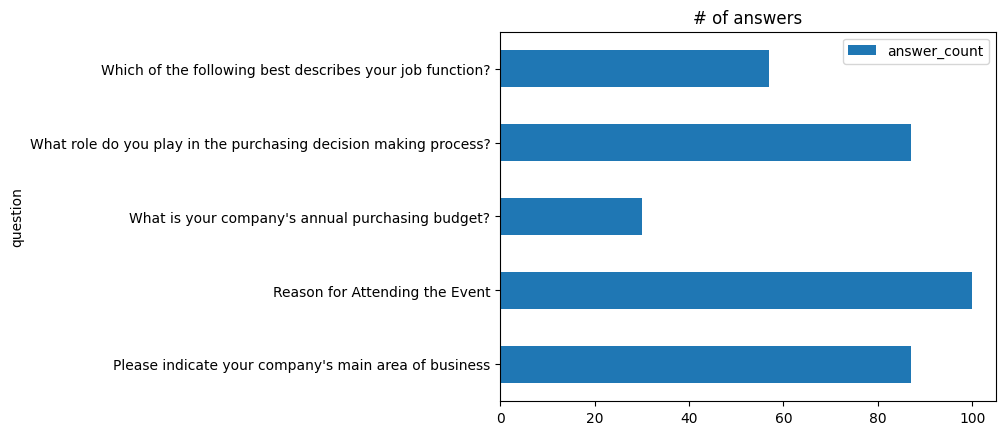

In [19]:
import matplotlib.pyplot as plt

top_qna.plot(kind='barh', title='# of answers')


Lets find the breakdown of answers for each question

In [29]:
answer_dist = visitor_data.groupby(['question', 'answer']).size().reset_index(name='count')
answer_dist

,question,answer,count
0,Please indicate your company's main area of bu...,Accommodation Provider,2
1,Please indicate your company's main area of bu...,Event management,9
2,Please indicate your company's main area of bu...,IT solutions for travel industry,3
3,Please indicate your company's main area of bu...,Tour Operator,19
4,Please indicate your company's main area of bu...,Travel Agent,54
5,Reason for Attending the Event,Educational purposes,8
6,Reason for Attending the Event,Personal interest,13
7,Reason for Attending the Event,To obtain general information,24
8,Reason for Attending the Event,To promote products and services,20
9,Reason for Attending the Event,To source products and services,35


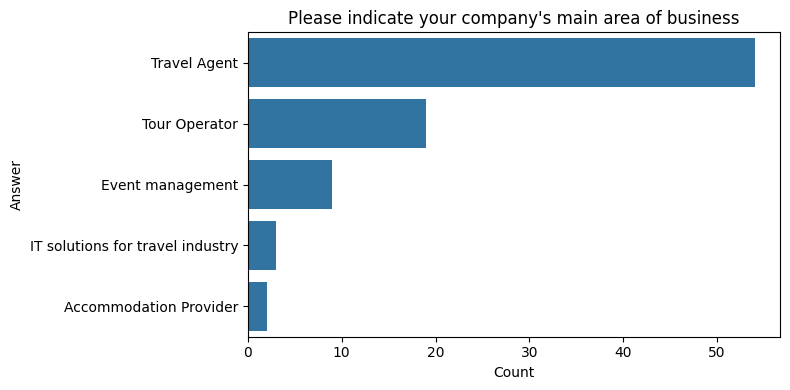

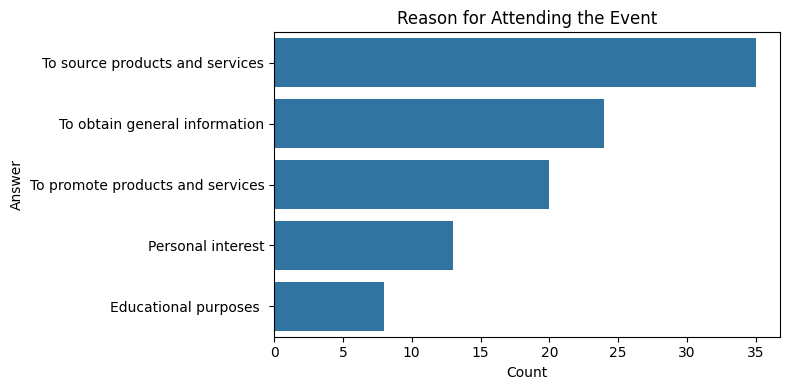

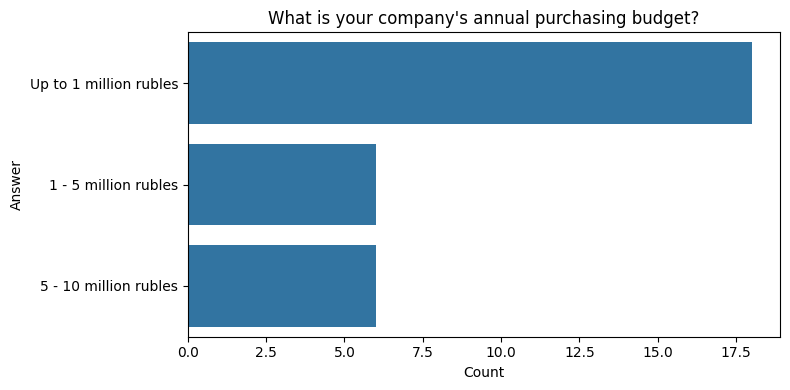

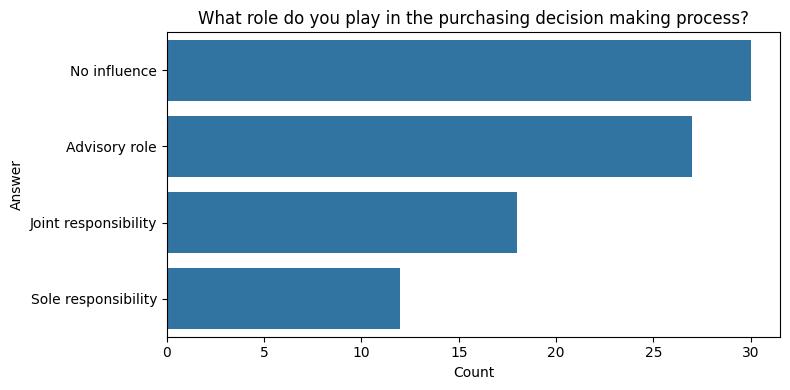

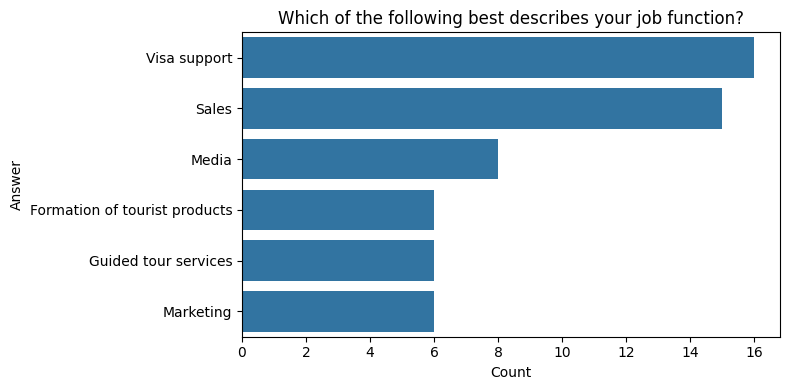

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

all_questions = answer_dist['question'].unique().tolist()

for q in all_questions:
    subset = answer_dist[answer_dist['question'] == q].sort_values('count', ascending=False)

    plt.figure(figsize=(8,4))
    sns.barplot(data=subset, y='answer', x='count')
    plt.title(q)
    plt.xlabel("Count")
    plt.ylabel("Answer")
    plt.tight_layout()
    plt.show()


These charts give us a thorough visibility of the visitor profile analysis.